## Conditional Graph

In [30]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [31]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation: str
    result: int

In [32]:
def addre(state: AgentState) -> AgentState:
    """Node addds the 2 numbers together and stores the result in the state."""
    state['result'] = state['number1'] + state['number2']
    return state

def subtractor(state: AgentState) -> AgentState:
    """Node subtracts the 2 numbers and stores the result in the state."""
    state['result'] = state['number1'] - state['number2']
    return state

def decide_next_node(state: AgentState) -> str:
    """Node decides which operation to perform based on the result of the addition."""
    if state['operation'] == '+':
        return "addition_operation"
    elif state['operation'] == '-':
        return "subtraction_operation"

In [33]:
graph = StateGraph(AgentState)

graph.add_node("add_node", addre)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state: state)  # Router node that decides which operation to perform

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router", 
    decide_next_node, 
    {
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }
)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

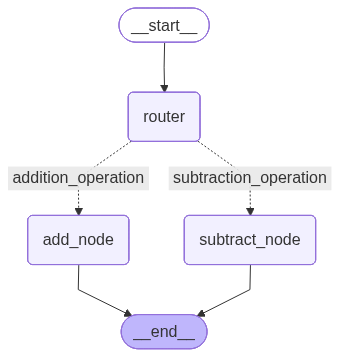

In [34]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
initial_state = AgentState(number1=10, number2=5, operation='+', result=0)
print(app.invoke(initial_state))  # Should perform addition and return the result

initial_state = AgentState(number1=10, number2=5, operation='-', result=0)
print(app.invoke(initial_state))  # Should perform subtraction and return the result

{'number1': 10, 'number2': 5, 'operation': '+', 'result': 15}
{'number1': 10, 'number2': 5, 'operation': '-', 'result': 5}
